In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *

In [2]:
class Lattice:
    def __init__(self, X, Y=None,
                 pbc_x=False, pbc_y=True):
        self.X = X
        Y = X if Y is None else Y
        self.Y = Y
        self.pbc_x=pbc_x
        self.pbc_y=pbc_y
        self.num_sites = X * Y

        edges_x = []
        edges_y = []
        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flat index for (x,y)

                # right neighbor (x+1, y)
                if x < X - 1:
                    edges_x.append((i, i + 1))
                elif pbc_x and X > 2:
                    edges_x.append((i, y * X))

                # down neighbor (x, y+1)
                if y < Y - 1:
                    edges_y.append((i, (y + 1) * X + x))
                elif pbc_y and Y > 2:
                    edges_y.append((i, x))
        self.edges_y = edges_y
        self.edges_x = edges_x

    def get_coords(self, i):
        y = i // self.X
        x = i % self.X
        return cp.asarray([x, y], dtype=int)

    def get_disp(self, i, j):
        ri = self.get_coords(i)  # [xi, yi]
        rj = self.get_coords(j)  # [xj, yj]
        dr = cp.subtract(rj, ri) # [dx, dy]

        Lx, Ly = self.X, self.Y
        if self.pbc_x:
            if dr[0] > Lx // 2:
                dr[0] -= Lx
            elif dr[0] < -Lx // 2:
                dr[0] += Lx

        if self.pbc_y:
            if dr[1] > Ly // 2:
                dr[1] -= Ly
            elif dr[1] < -Ly // 2:
                dr[1] += Ly

        return dr
    
    def get_dir(self, i, j):
        dr = self.get_disp(i, j)
        if dr[0] == 1 and dr[1] == 0:
            return "+x"
        elif dr[0] == -1 and dr[1] == 0:
            return "-x"
        elif dr[0] == 0 and dr[1] == 1:
            return "+y"
        elif dr[0] == 0 and dr[1] == -1:
            return "-y"
        
    def get_edge_and_bulk_indices(X, Y, edge_width=1):
        edge_indices = []
        bulk_indices = []

        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flattened index

                if x < edge_width or x >= X - edge_width or y < edge_width or y >= Y - edge_width:
                    edge_indices.append(i)
                else:
                    bulk_indices.append(i)

        return edge_indices, bulk_indices

    def plot(self, highlight=None, path=None):
        fig, ax = plt.subplots(figsize=(6, 6))
        coords = {}

        for y in range(self.Y):
            for x in range(self.X):
                i = y * self.X + x
                coords[i] = (x, -y)

        for i, j in self.edges_x + self.edges_y:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot([x1, x2], [y1, y2], 'k-', lw=1)

        for i, (xx, yy) in coords.items():
            ax.plot(xx, yy, 'ro')
            ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                    color="white", bbox=dict(facecolor="black",
                                             edgecolor="none",
                                             boxstyle="circle,pad=0.25"))
            if highlight is not None and i in highlight:
                ax.plot(xx, yy, 'ro')
                ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                        color="black", bbox=dict(facecolor="red",
                                                edgecolor="none",
                                                boxstyle="circle,pad=0.25"))

        ax.set_aspect("equal")
        ax.axis("off")
        if path is not None:
            plt.savefig(path, bbox_inches='tight')
        plt.show()


In [3]:
def delta(x, eta=1e-6): # Lorentzian approximation of delta function
    return eta / (cp.pi * (eta**2 + x**2))

def lorentzian(x, eta=1e-6):
    return eta / (cp.pi * (x**2 + eta**2))

def fermi_dirac(energy, T=1e-6):
    if T == 0:
        return cp.zeros_like(energy)
    else:
        return 1.0 / (cp.exp((energy) / T) + 1.0)

In [63]:
class Hamiltonian:
    def __init__(self, t, mu, lattice,
                 U=None, V=None, V_prime=None):
        
        '''
        Builds k-independent Hamiltonian matrix 
        '''
        self.lattice = lattice
        Nx = lattice.X
        dim = 4 * Nx

        if U is None:
            U = cp.zeros(Nx)
        if V is None:
            V = cp.zeros(Nx-1)
        if V_prime is None:
            V_prime = cp.zeros(Nx-1)
        
        self.F0 = cp.zeros(Nx, dtype=cp.complex128)+1
        
        self.Fx_plus = cp.zeros(Nx-1, dtype=cp.complex128) +1
        self.Fx_min = cp.zeros(Nx-1, dtype=cp.complex128)+1
        self.Fy_plus = cp.zeros(Nx, dtype=cp.complex128)+1j
        self.Fy_min = cp.zeros(Nx, dtype=cp.complex128)+1j

        self.Fuu_xplus = cp.zeros(Nx-1, dtype=cp.complex128)+1
        self.Fuu_xmin = cp.zeros(Nx-1, dtype=cp.complex128)+1
        self.Fuu_yplus = cp.zeros(Nx, dtype=cp.complex128)+1j
        self.Fuu_ymin = cp.zeros(Nx, dtype=cp.complex128)+1j

        self.Fdd_xplus = cp.zeros(Nx-1, dtype=cp.complex128)+1
        self.Fdd_xmin = cp.zeros(Nx-1, dtype=cp.complex128)+1
        self.Fydd_yplus = cp.zeros(Nx, dtype=cp.complex128)+1j
        self.Fydd_ymin = cp.zeros(Nx, dtype=cp.complex128)+1j
        
        print(self.Fx_plus.shape)
        gap0 = U * self.F0
        gap1 = V * self.Fx_min
        gap2 = V * self.Fx_plus
        gap1_uu = V_prime * self.Fuu_xmin
        gap2_uu = V_prime * self.Fuu_xplus
        gap1_dd = V_prime * self.Fuu_xmin
        gap2_dd = V_prime * self.Fuu_xplus
        
        self.matrix = cp.zeros((dim, dim), dtype=cp.complex128)
        
        diag = - mu #- 2.0 * t *cos(0)
        # set in diagonal elements (mu + 2cos(0))
        for i in range(lattice.X):
            sl = slice(4 * i, 4 * i + 4)
            self.matrix[sl,sl] += cp.diag(cp.array(
                [diag, diag, -diag, -diag]
            ))

            # set in BCS gap
            block = cp.zeros((4, 4), dtype=cp.complex128)
            block[0, 3] = gap0[i]
            block[1, 2] = -gap0[i].conj()
            block[2, 1] = -gap0[i].conj()
            block[3, 0] = gap0[i]
            self.matrix[sl,sl] += block

        # set in hopping block in x direction
        for i in range(Nx-1):
            idx = i % (Nx-1)
            sli = slice(4 * i, 4 * i + 4)
            slj = slice(4 * (i + 1), 4 * (i + 1) + 4)
            self.matrix[sli,slj] += cp.diag(cp.array(
                [-t, -t, t, t]
            ))
            self.matrix[slj,sli] += cp.diag(cp.array(
                [-t, -t, t, t]
            ))

            # x+
            upper = cp.zeros((4, 4), dtype=cp.complex128)
          
            upper[0, 3] = gap2[idx]
            upper[1, 2] = -gap1[idx]
            upper[2, 1] = -gap2[idx].conj()
            upper[3, 0] = gap1[idx].conj()

            upper[0, 2] = gap2_uu[idx]
            upper[1, 3] = gap2_dd[idx]
            upper[2, 0] = gap1_uu[idx].conj()
            upper[3, 1] = gap1_dd[idx].conj()

            # x-
            lower = cp.zeros((4, 4), dtype=cp.complex128)
            lower[0, 3] = gap1[idx]
            lower[1, 2] = -gap2[idx]
            lower[2, 1] = -gap1[idx].conj()
            lower[3, 0] = gap2[idx].conj()

            lower[0, 2] = gap1_uu[idx]
            lower[1, 3] = gap1_dd[idx]
            lower[2, 0] = gap2_uu[idx].conj()
            lower[3, 1] = gap2_dd[idx].conj()

            self.matrix[sli, slj] += upper
            self.matrix[slj, sli] += lower

    def is_hermitian(self, atol=1e-8, rtol=1e-6):
        if self.matrix is None:
            raise RuntimeError("Hamiltonian matrix not built yet. "
                               "Call build() first.")
        is_hermitian = cp.allclose(self.matrix, self.matrix.conj().T, rtol=rtol, atol=atol)
        return is_hermitian

    def diagonalize(self, drop_matrix=False):
        if self.matrix is None:
            raise RuntimeError("Hamiltonian matrix not built yet. "
                               "Call build() first.")
        eigenvalues, eigenvectors = cp.linalg.eigh(self.matrix)

        if drop_matrix:
            self.matrix = None
        return eigenvalues, eigenvectors

    def dos(self, energies, eta, idx=None, drop_matrix=False):
        evals, evecs = self.diagonalize(drop_matrix=drop_matrix)
        dos_values = cp.zeros_like(energies)

        N = self.lattice.num_sites
        M = evals.size  # should be 4*N
        for k in range(M):
            E = evals[k]
            if E < 0:
                continue  # skip negative ones

            col = evecs[:, k]

            if idx is None:
                # (4N,) -> (N,4)
                col_site = col.reshape(N, 4)
                u_up = col_site[:, 0]
                u_dn = col_site[:, 1]
                v_up = col_site[:, 2]
                v_dn = col_site[:, 3]

                w_pos = cp.sum(cp.abs(u_up)**2 + cp.abs(u_dn)**2)
                w_neg = cp.sum(cp.abs(v_up)**2 + cp.abs(v_dn)**2)
            else:
                base = 4 * idx
                u_up = col[base + 0]
                u_dn = col[base + 1]
                v_up = col[base + 2]
                v_dn = col[base + 3]

                w_pos = cp.sum(cp.abs(u_up)**2 + cp.abs(u_dn)**2)
                w_neg = cp.sum(cp.abs(v_up)**2 + cp.abs(v_dn)**2)

            dos_values += w_pos * lorentzian(energies - E, eta=eta)
            dos_values += w_neg * lorentzian(energies + E, eta=eta)

        del evecs, evals
        cp.get_default_memory_pool().free_all_blocks()

        return dos_values / energies.size

    def ldos(self, energies, eta, edge_width=3, asnumpy=True):
        X = self.lattice.X
        Y = self.lattice.Y
        N = X * Y

        i = cp.arange(N)          # 0, 1, ..., N-1
        x = i % X                 # column (0 ... X-1)
        y = i // X                # row    (0 ... Y-1)

        edge_mask = ((x < edge_width-1) | (x >= X - edge_width) | (y < edge_width-1) | (y >= Y - edge_width))
        edge_idx = i[edge_mask]
        bulk_idx = i[~edge_mask]
        if asnumpy:
            total_dos = self.dos(energies, eta=eta,drop_matrix=False)
            np_total_dos = cp.asnumpy(total_dos)
            del total_dos
            ldos_edge = self.dos(energies,eta=eta,idx=edge_idx,drop_matrix=False)
            np_ldos_edge = cp.asnumpy(ldos_edge)
            del ldos_edge
            ldos_bulk = self.dos(energies,eta=eta,idx=bulk_idx,drop_matrix=False)
            np_ldos_bulk = cp.asnumpy(ldos_bulk)
            del ldos_bulk
            return np_total_dos, np_ldos_edge, np_ldos_bulk
        else:
            total_dos = self.dos(energies, eta=eta,drop_matrix=False)
            ldos_edge = self.dos(energies,eta=eta,idx=edge_idx,drop_matrix=False)
            ldos_bulk = self.dos(energies,eta=eta,idx=bulk_idx,drop_matrix=False)
            return total_dos, ldos_edge, ldos_bulk


In [64]:
def bdg_self_consistency_step(H,  # Hamiltonian
                              U=None, V=None, V_prime=None, T=0,  # Parameters
                              atol=1e-6, rtol=1e-4, mix=1.0):  # Tolerances
    pass

In [65]:
t = 1
mu = -1.8* t
X, Y = 10,10

lattice = Lattice(X, Y)

U0 = 2.0 * t 
U = U0 * cp.ones(lattice.X)
V0 = 2.0 * t 
V = V0 * cp.ones(lattice.X-1)

H = Hamiltonian(t,mu,lattice, V = V)

(9,)


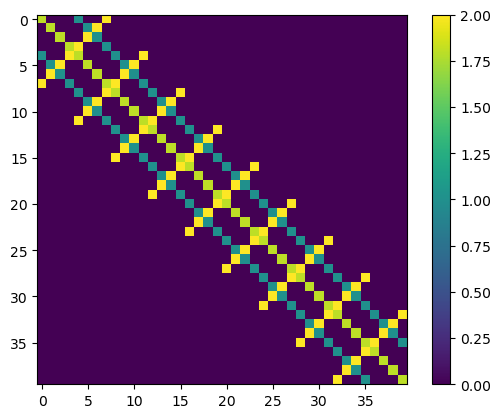

In [66]:
plt.figure()
plt.imshow(cp.asnumpy(cp.abs(H.matrix)))
plt.colorbar()

In [62]:
print(H.is_hermitian())

True


In [ ]:
ky_list = cp.linspace(PI / Y, PI, Y)

# Initial values for order parameter (MATLAB)
Fx_plus = 0.1 * cp.ones(X - 1, dtype=cp.complex128)
Fx_min  = -0.1 * cp.ones(X - 1, dtype=cp.complex128)
Fy_plus = 0.1j * cp.ones(X, dtype=cp.complex128)
Fy_min  = -0.1j * cp.ones(X, dtype=cp.complex128)

